# 🎹 [실습] 삼각함수로 소리 파형 만들고 FFT로 분해해보기
> **수업 대상**: 코딩을 처음 배우는 고등학교 1학년 (초심자 환영!)
> **준비물**: 구글 코랩(Google Colab)
> **선수 지식**: 1차시의 파형·주파수 개념 (사인파 정도만 알면 OK!)
---
### 📋 이 실습에서 배우는 것 (3줄 요약)
1. 🎵 **삼각함수(sin)**로 도·레·미 소리 파형을 직접 만들고 들어보기
2. 🔬 여러 소리를 섞은 뒤 **FFT(푸리에 변환)**로 어떤 주파수가 섞였는지 분해해보기
3. 🧩 가장 큰 성분 몇 개만으로 원래 소리를 **다시 합성(복원)**해보기
---
### 🚀 실행 순서
- 셀 1~3: `record_apple.wav`(직접 녹음한 사과 발음 파일)로 파형·스펙트럼 실험하기
- 셀 4~5: 녹음 파일 없이도 바로 실행! 삼각함수 합성과 도레미 실험하기

> ⚠️ **참고**: 셀 1~3은 `record_apple.wav` 파일이 같은 폴더에 있어야 실행돼요. 파일이 없으면 셀 4~5부터 먼저 실습하세요!
> ✅ **체크포인트**: 셀 4를 실행했더니 440Hz·500Hz·1000Hz 그래프와 소리가 나왔다 → 성공! 🎉


In [ ]:
#한글을 그래프에 보여주는 라이브러리
!pip install koreanize_matplotlib
import koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 49.4 MB/s eta 0:00:00


sampling rate: 44100
time: 1.310453514739229
vData: [[ -30  -50]
 [ -47  -74]
 [ 101  118]
 [-182 -192]
 [ 122  138]
 [-179 -204]
 [ -75 -112]
 [ -51  -56]
 [ 144  144]]


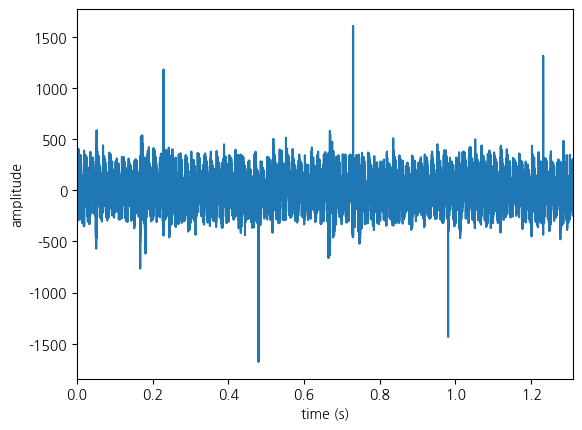

mono: [ -40.   -60.5  109.5 -187.   130.  -191.5  -93.5  -53.5  144. ]


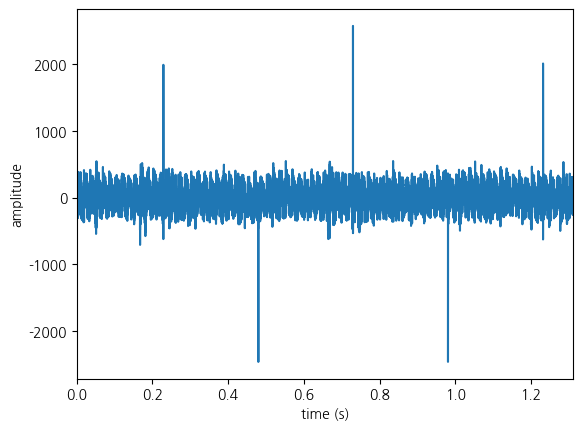

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile

v_sample,v_data=scipy.io.wavfile.read("record_apple.wav")
time=np.arange(len(v_data))/float(v_sample)

print('sampling rate:', v_sample)
print('time:', time[-1])
print('vData:', v_data[-10:-1])

plt.plot(time, v_data[:,0])
plt.xlim(time[0], time[-1])
plt.xlabel('time (s)')
plt.ylabel('amplitude')
plt.show()
mono = np.mean(np.asarray(v_data, dtype=np.float32), axis=1)
print('mono:', mono[-10:-1])
plt.plot(time, mono)
plt.xlim(time[0], time[-1])
plt.xlabel('time (s)')
plt.ylabel('amplitude')
plt.show()

In [ ]:
from IPython.display import Audio
# 스테레오면 평균내어 모노로 (v_data가 int16이면 평균값도 int16 범위 안의 실수)
mono = np.mean(v_data, axis=1) if v_data.ndim == 2 else v_data
mono = np.asarray(mono, dtype=np.float64)
# -1 ~ +1 범위로 정규화한 뒤 int16으로 변환 (그냥 32767을 곱하면 숫자가 넘쳐서 소리가 깨져요!)
mono = mono / (np.max(np.abs(mono)) + 1e-12)
mono = (mono * 32767).astype(np.int16)
rate = int(v_sample)
display(Audio(mono, rate=rate, autoplay=True))

Sampling rate: 44100 Hz
Duration used: 1.3104761904761906 s


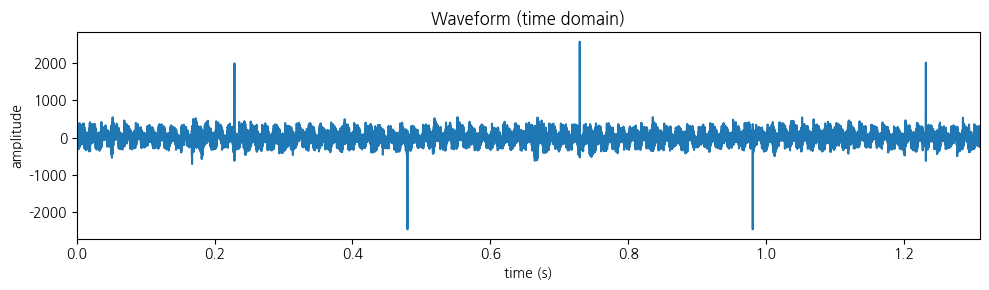

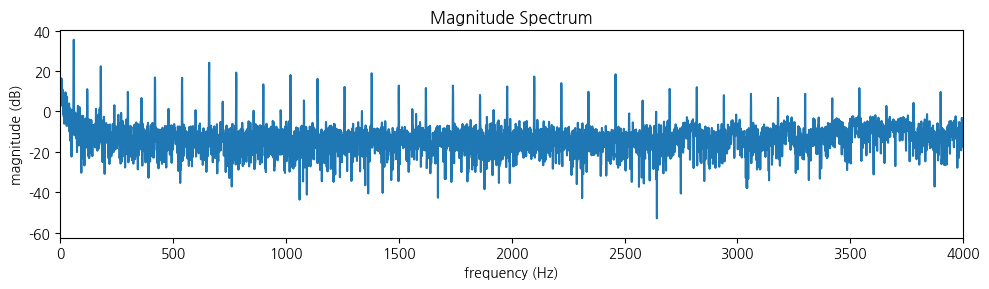

Top frequencies (Hz): [60.3]


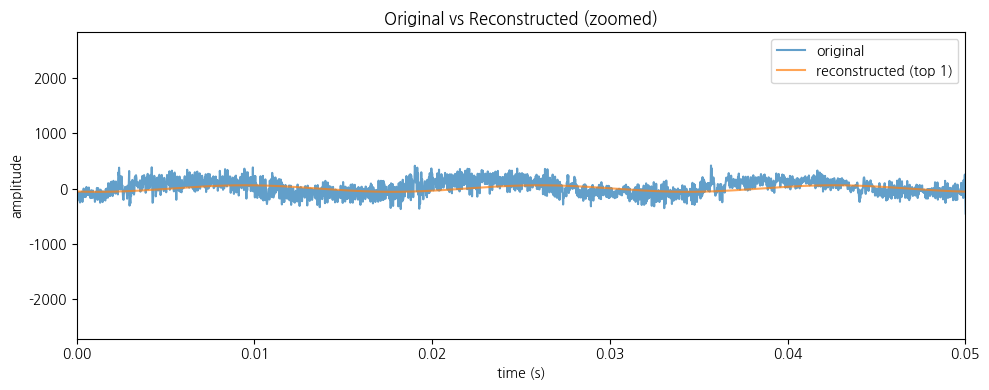

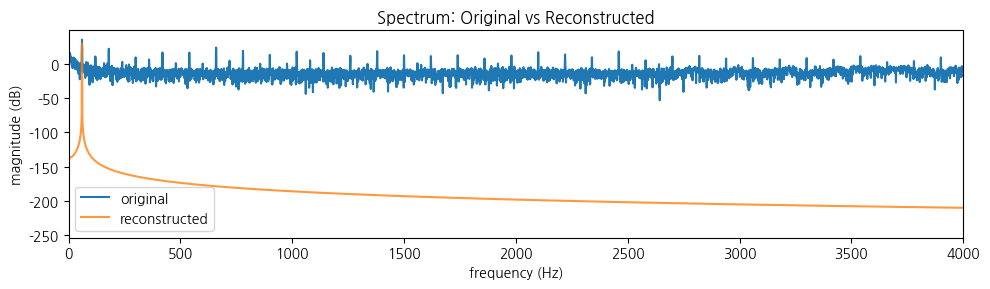

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav

# 1) 오디오 파일 불러오기 & 모노 변환 (+ 정규화)
# (녹음 파일이 int16 숫자들로 저장되어 있을 수 있어요)
sr, v_data = wav.read("record_apple.wav")  # int16일 가능성 큼
v_data = np.asarray(v_data)

# 스테레오 -> 모노
if v_data.ndim == 2:
    mono = v_data.mean(axis=1)
else:
    mono = v_data.astype(np.float64)

# float로 정규화(-1~1)
if mono.dtype.kind in ['i', 'u']:  # int형이면
    mono = mono.astype(np.float64)
    max_abs = np.max(np.abs(mono)) + 1e-12
    mono = mono / max_abs

# 2) (선택) 일부 구간만 사용해 빠르게 시연
sec = 2.0
N = int(min(len(mono), sec * sr))
x = mono[:N]
t = np.arange(N) / sr

print("Sampling rate:", sr, "Hz")
print("Duration used:", len(x) / sr, "s")

# 3) 시간영역 파형
plt.figure(figsize=(10,3))
plt.plot(t, x)
plt.xlim(0, t[-1])
plt.xlabel("time (s)")
plt.ylabel("amplitude")
plt.title("Waveform (time domain)")
plt.tight_layout()
plt.show()

# 4) 창 함수(해밍)로 누설 줄이고 FFT
window = np.hamming(N)
xw = x * window

# rFFT: 양의 주파수만
X = np.fft.rfft(xw)
freqs = np.fft.rfftfreq(N, d=1/sr)

# 창 보정(대략적): 진폭 스케일
# 단위일관성보다 비교/시각화가 목적이므로 상대비교 위주
mag = np.abs(X) / (N/2)
phase = np.angle(X)

# 5) 스펙트럼(진폭)
plt.figure(figsize=(10,3))
plt.plot(freqs, 20*np.log10(mag + 1e-12))
plt.xlim(0, 4000)  # 보기 좋게 4kHz까지
plt.xlabel("frequency (Hz)")
plt.ylabel("magnitude (dB)")
plt.title("Magnitude Spectrum")
plt.tight_layout()
plt.show()

# 6) 가장 큰 성분 topK개만으로 소리 다시 만들기 (코사인 합성)
# 마치 레고 블록 몇 개로 원래 모양을 흉내 내는 것과 같아요! 🧩
topK = 1  # ← 슬라이더로 바꾸면 훨씬 재밌음!
# 0Hz(DC) 제외하고 큰 진폭 순 인덱스 선정
idx = np.argsort(mag[1:])[-topK:] + 1
idx = idx[np.argsort(mag[idx])[::-1]]  # 내림차순 정렬

print("Top frequencies (Hz):", np.round(freqs[idx], 1))

# 코사인 합성: A*cos(2π f t + phi)
x_hat = np.zeros_like(x)
for k in idx:
    Ak = mag[k]
    fk = freqs[k]
    phik = phase[k]
    x_hat += Ak * np.cos(2*np.pi*fk*t + phik)

# 7) 원 신호 vs 재합성 비교
plt.figure(figsize=(10,4))
plt.plot(t, x, label="original", alpha=0.7)
plt.plot(t, x_hat, label=f"reconstructed (top {topK})", alpha=0.7)
plt.xlim(0, min(t[-1], 0.05))  # 50ms 확대해서 파형 비교
plt.xlabel("time (s)")
plt.ylabel("amplitude")
plt.title("Original vs Reconstructed (zoomed)")
plt.legend()
plt.tight_layout()
plt.show()

# 8) 재합성 스펙트럼 확인(선택)
Xhat = np.fft.rfft(x_hat * window)
mag_hat = np.abs(Xhat) / (N/2)

plt.figure(figsize=(10,3))
plt.plot(freqs, 20*np.log10(mag + 1e-12), label="original")
plt.plot(freqs, 20*np.log10(mag_hat + 1e-12), label="reconstructed", alpha=0.8)
plt.xlim(0, 4000)
plt.xlabel("frequency (Hz)")
plt.ylabel("magnitude (dB)")
plt.title("Spectrum: Original vs Reconstructed")
plt.legend()
plt.tight_layout()
plt.show()


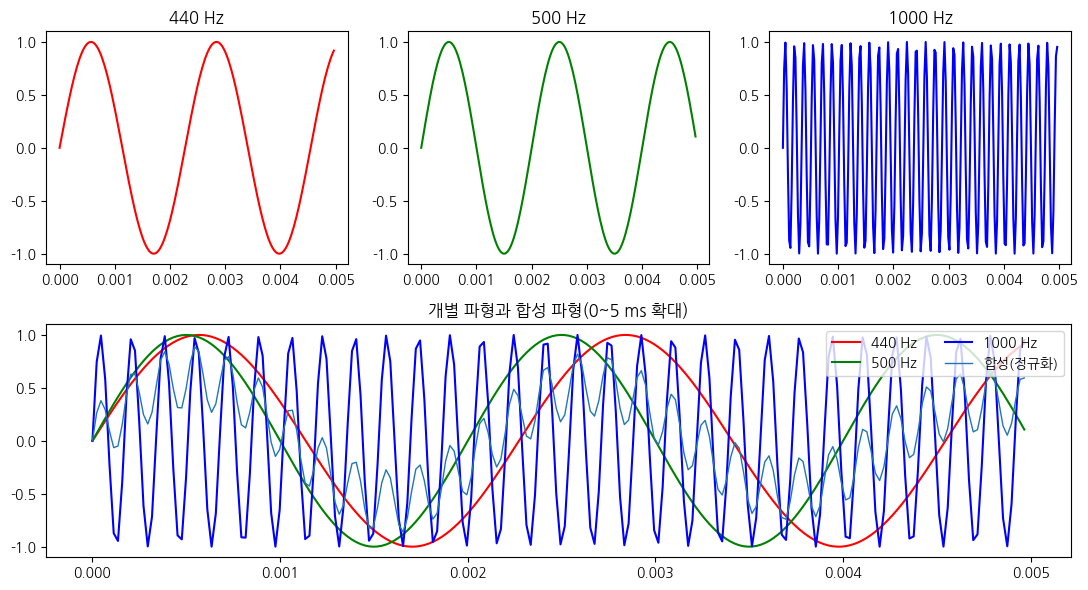

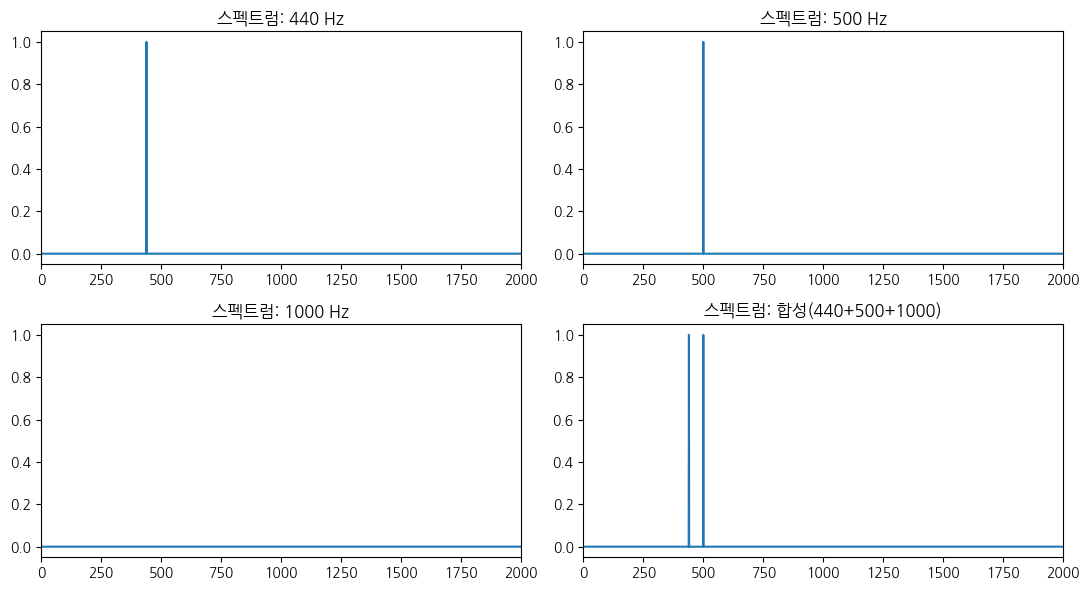

▶ 440 Hz


▶ 500 Hz


▶ 1000 Hz


▶ 합성: 440 + 500 + 1000 Hz


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

# ---------------- 기본 설정 ----------------
fs = 44100          # 샘플링 주파수(Hz)
duration = 2.0      # 재생 시간(초)
t = np.linspace(0, duration, int(fs*duration), endpoint=False)

# 대상 주파수
f1, f2, f3 = 440, 500, 1000  # 1000Hz: 제목과 일치하도록 수정 (50000Hz는 44100Hz 샘플링의 나이퀴스트 한계를 초과)

# 사인파 생성
y1 = np.sin(2*np.pi*f1*t)
y2 = np.sin(2*np.pi*f2*t)
y3 = np.sin(2*np.pi*f3*t)

# 합성(정규화로 클리핑 방지)
y_sum = y1 + y2 + y3
y_sum = y_sum / np.max(np.abs(y_sum)) * 0.9  # -1~1 범위 내로

# ---------------- 시각화(시간영역) ----------------
# 5ms 구간만 확대해서 파형 비교 (그림과 유사한 배치)
idx = int(0.005 * fs)  # 0~5ms
plt.figure(figsize=(11,6))

plt.subplot(2,3,1)
plt.plot(t[:idx], y1[:idx], 'r')
plt.title("440 Hz")
plt.ylim(-1.1, 1.1)

plt.subplot(2,3,2)
plt.plot(t[:idx], y2[:idx], 'g')
plt.title("500 Hz")
plt.ylim(-1.1, 1.1)

plt.subplot(2,3,3)
plt.plot(t[:idx], y3[:idx], 'b')
plt.title("1000 Hz")
plt.ylim(-1.1, 1.1)

plt.subplot(2,1,2)
plt.plot(t[:idx], y1[:idx], 'r', label='440 Hz')
plt.plot(t[:idx], y2[:idx], 'g', label='500 Hz')
plt.plot(t[:idx], y3[:idx], 'b', label='1000 Hz')
plt.plot(t[:idx], y_sum[:idx], label='합성(정규화)', linewidth=1)
plt.title("개별 파형과 합성 파형(0~5 ms 확대)")
plt.legend(loc='upper right', ncol=2)
plt.ylim(-1.1, 1.1)

plt.tight_layout()
plt.show()

# ---------------- 시각화(주파수 스펙트럼) ----------------
def mag_spectrum(y, fs):
    # 단면 스펙트럼(양수 주파수만)
    Y = np.fft.rfft(y * np.hanning(len(y)))
    f = np.fft.rfftfreq(len(y), 1/fs)
    mag = np.abs(Y) / np.max(np.abs(Y))  # 상대크기(정규화)
    return f, mag

f_y1, m_y1 = mag_spectrum(y1, fs)
f_y2, m_y2 = mag_spectrum(y2, fs)
f_y3, m_y3 = mag_spectrum(y3, fs)
f_sum, m_sum = mag_spectrum(y_sum, fs)

plt.figure(figsize=(11,6))
plt.subplot(2,2,1)
plt.plot(f_y1, m_y1); plt.xlim(0, 2000); plt.title("스펙트럼: 440 Hz")

plt.subplot(2,2,2)
plt.plot(f_y2, m_y2); plt.xlim(0, 2000); plt.title("스펙트럼: 500 Hz")

plt.subplot(2,2,3)
plt.plot(f_y3, m_y3); plt.xlim(0, 2000); plt.title("스펙트럼: 1000 Hz")

plt.subplot(2,2,4)
plt.plot(f_sum, m_sum); plt.xlim(0, 2000); plt.title("스펙트럼: 합성(440+500+1000)")
plt.tight_layout()
plt.show()

# ---------------- 소리 재생 ----------------
print("▶ 440 Hz")
display(Audio(y1, rate=fs))
print("▶ 500 Hz")
display(Audio(y2, rate=fs))
print("▶ 1000 Hz")
display(Audio(y3, rate=fs))
print("▶ 합성: 440 + 500 + 1000 Hz")
display(Audio(y_sum, rate=fs))


도 (C4) ≈ 261.63 Hz
레 (D4) ≈ 293.66 Hz
미 (E4) ≈ 329.63 Hz


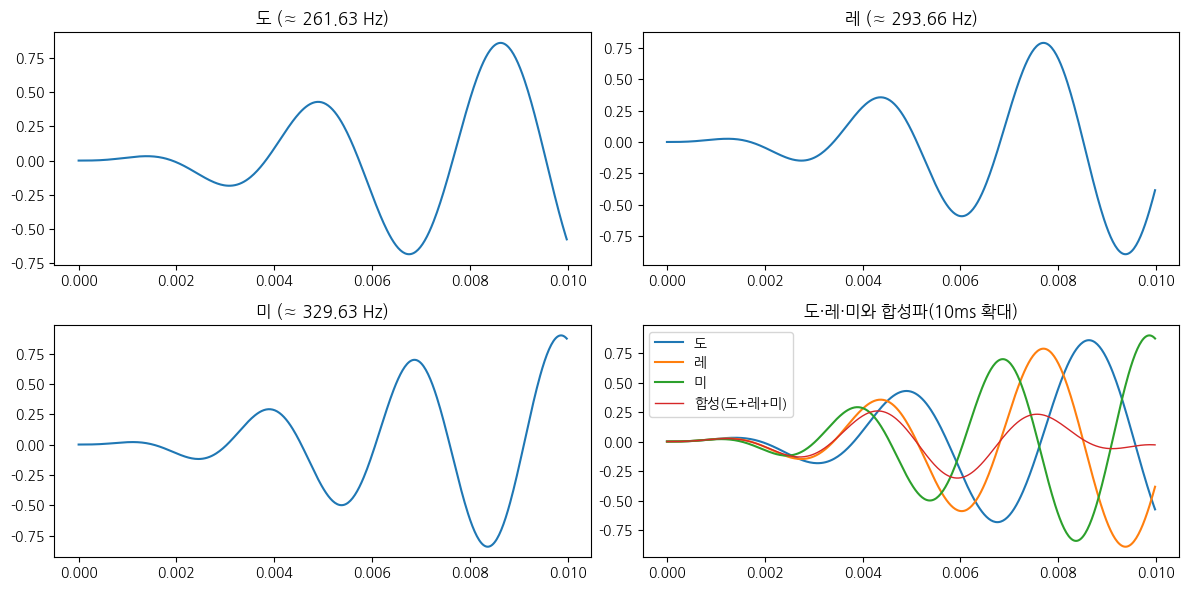

▶ 도


▶ 레


▶ 미


▶ 합성(도+레+미)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

# ===== 설정 =====
fs = 44100            # 샘플링 주파수
duration = 2.0        # 각 음의 재생 시간(초)
octave = 4            # 4 옥타브: C4=261.63 Hz (중앙 도)

# ===== 유틸: MIDI <-> 주파수 =====
def midi_to_freq(m):
    return 440.0 * (2.0 ** ((m - 69) / 12.0))

# 도레미(C,D,E)의 MIDI 번호 계산 (12평균율, 고정도)
# MIDI 규약: C0=12, C4=60 -> note_num = 12*(octave+1) + index
NOTE_INDEX = {'도': 0, '레': 2, '미': 4}  # C,D,E
def solfege_to_midi(name, octave=4):
    return 12 * (octave + 1) + NOTE_INDEX[name]

# ===== 파형 생성 =====
t = np.linspace(0, duration, int(fs*duration), endpoint=False)

# 간단한 페이드(클릭 방지)
def fade_in_out(y, fs, fade_ms=10):
    n = int(fs * fade_ms / 1000)
    if n == 0:
        return y
    w = np.ones_like(y)
    # cos 페이드
    ramp = 0.5 * (1 - np.cos(np.linspace(0, np.pi, n)))
    w[:n] = ramp
    w[-n:] = ramp[::-1]
    return y * w

names = ['도', '레', '미']
midis = [solfege_to_midi(n, octave) for n in names]
freqs = [midi_to_freq(m) for m in midis]

# 사인파 생성(+페이드, 레벨 여유)
waves = []
for f in freqs:
    y = np.sin(2*np.pi*f*t)
    y = fade_in_out(y, fs, fade_ms=10)
    y *= 0.9
    waves.append(y)

y_do, y_re, y_mi = waves
y_sum = (y_do + y_re + y_mi)
y_sum = y_sum / np.max(np.abs(y_sum)) * 0.9  # 합성은 정규화

# ===== 정보 출력 =====
for n, f in zip(names, freqs):
    print(f"{n} ({'CDE'[names.index(n)]}{octave}) ≈ {f:.2f} Hz")

# ===== 시각화(시간영역: 10ms 확대) =====
idx = int(0.010 * fs)  # 10ms
plt.figure(figsize=(12,6))

plt.subplot(2,2,1)
plt.plot(t[:idx], y_do[:idx])
plt.title(f"도 (≈ {freqs[0]:.2f} Hz)")

plt.subplot(2,2,2)
plt.plot(t[:idx], y_re[:idx])
plt.title(f"레 (≈ {freqs[1]:.2f} Hz)")

plt.subplot(2,2,3)
plt.plot(t[:idx], y_mi[:idx])
plt.title(f"미 (≈ {freqs[2]:.2f} Hz)")

plt.subplot(2,2,4)
plt.plot(t[:idx], y_do[:idx], label="도")
plt.plot(t[:idx], y_re[:idx], label="레")
plt.plot(t[:idx], y_mi[:idx], label="미")
plt.plot(t[:idx], y_sum[:idx], label="합성(도+레+미)", linewidth=1)
plt.title("도·레·미와 합성파(10ms 확대)")
plt.legend()
plt.tight_layout()
plt.show()

# ===== 재생 =====
print("▶ 도")
display(Audio(y_do, rate=fs))
print("▶ 레")
display(Audio(y_re, rate=fs))
print("▶ 미")
display(Audio(y_mi, rate=fs))
print("▶ 합성(도+레+미)")
display(Audio(y_sum, rate=fs))
